In [ ]:
# =========================================================
# --- Opcjonalnie : montowanie Google Drive ---
# =========================================================
from google.colab import drive
import os

# Montowanie dysku Google
drive.mount('/content/drive')

# Ścieżka do folderu roboczego na Drive
base_export_dir = '/content/drive/MyDrive/colab_cifar10_exports'
os.makedirs(base_export_dir, exist_ok=True)

print(f"[OK] Google Drive podłączony. Pliki będą zapisywane w:\n{base_export_dir}")

Mounted at /content/drive
[OK] Google Drive podłączony. Pliki będą zapisywane w:
/content/drive/MyDrive/colab_cifar10_exports


In [64]:
# =========================================================
# --- 0. Import bibliotek ---
# =========================================================
import os
import datetime
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    Activation,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Etykieta przykładowego obrazu: [9]


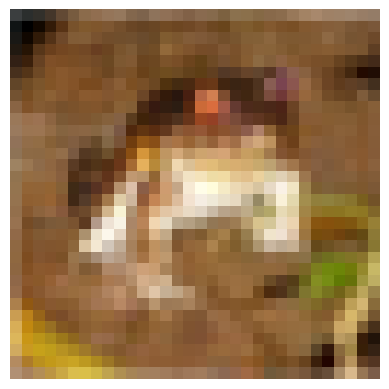

In [65]:
# =========================================================
# --- 1. Importowanie danych CIFAR10 ---
# =========================================================
# Wczytanie zbioru danych CIFAR10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Wyświetlenie przykładowego obrazu (opcjonalne)
print("Etykieta przykładowego obrazu:", y_train[2])
plt.imshow(x_train[0])
plt.axis('off')
plt.show()

In [66]:
# =========================================================
# --- 2. Wstępne przetwarzanie danych ---
# =========================================================
# Normalizacja do zakresu [0,1] i dodanie kanału (H,W,1)
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# One-hot encoding etykiet
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

# lista nazw klas CIFAR-10 (użyteczna w wyświetleniach)
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [75]:
# =========================================================
# --- 3. Model  ---
# =========================================================

input_shape = (32, 32, 3)            # CIFAR-10 to 32x32 RGB

def build_model(input_shape=(32,32,3), num_classes=10):
    model = Sequential([
        Input(shape=input_shape),                  # oczekiwany kształt obrazka: 32x32 piksele, 3 kanały (RGB)

        # Block 1 uczy się 32 filtrów 3x3
        Conv2D(32, (3,3), padding='same'),         # pierwsza konwolucja — padding='same' → wyjście ma taki sam rozmiar jak wejście
        BatchNormalization(),                      # normalizuje aktywacje — stabilizuje trening
        Activation('relu'),                        # nieliniowość → sieć może uczyć się skomplikowanych zależności
        Conv2D(32, (3,3), padding='same'),         # druga konwolucja — jeszcze głębsze wyciąganie cech
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),                       # zmniejsza rozdzielczość o 2× (32→16) i zachowuje najważniejsze cechy
        Dropout(0.2),                              # dropout 20% — redukuje overfitting, losowo wyzerowując neurony

        # Block 2 uczy się 64 filtrów 3x3
        Conv2D(64, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(64, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),
        Dropout(0.3),                            # jszcze większy dropout, by uniknąć overfittingu (przeuczenia)

        # Block 3 uczy się 128 filtrów 3x3
        Conv2D(128, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(128, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D((2,2)),
        Dropout(0.4),

        # uśredniamy globalnie cechy -> model ma MNIEJ parametrow i uczy się stabilniej
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),             # Gęsta warstwa — 128 neuronów
        BatchNormalization(),
        Dropout(0.4),                              # jeszcze większy dropout, by uniknąć overfittingu (przeuczenia)
        Dense(num_classes, activation='softmax')   # OUTPUT —> 10 klas z softmaxem (zmienia wyjscia neuronow na prawdopodobienstow)
    ])
    return model

model = build_model(input_shape, num_classes)
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 8, 8, 128)      │             

 Total params: 307,114 (1.17 MB)

 Trainable params: 305,962 (1.17 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [76]:
# =========================================================
# --- 4. Kompilacja modelu ---
# =========================================================

# Optymalizator Adam, funkcja straty categorical_crossentropy, metryka accuracy
initial_lr = 1e-3
model.compile(
    optimizer=Adam(learning_rate=initial_lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Wyświetlenie podsumowania modelu
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 8, 8, 128)      │             

 Total params: 307,114 (1.17 MB)

 Trainable params: 305,962 (1.17 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [77]:
# =========================================================
# --- 5. Callbacks ---
# =========================================================

# Data skończenia treningu - timestamp - znacznik do zapisywania plików
ts = datetime.datetime.now().strftime("_%Y%m%d_%H%M%S")
checkpoint_path = os.path.join(base_export_dir, f"best_model{ts}.keras")

#przerwie trening jeśli nie ma poprawy
es = EarlyStopping(
    monitor='val_loss',                # metryka, którą obserwujemy
    patience=15,                        # liczba epok bez poprawy, po których zatrzymujemy trening
    min_delta=1e-4,                    # minimalna wymagana zmiana, by uznać, że jest „poprawa”
    mode='min',                        # 'min' jeśli monitorujemy straty, 'max' jeśli dokładność
    restore_best_weights=True          # zapamiętanie najlepszego z wyników
)

#zmniejszy learning rate, jeśli walidacja stoi w miejscu
rlp = ReduceLROnPlateau(
    monitor='val_loss',                # metryka do obserwacji
    factor=0.5,                        # ile razy zmniejszyć LR (tu: o połowę)
    patience=4,                        # liczba epok bez poprawy przed zmniejszeniem LR, rlp.patience < es.patience
    min_delta=1e-4,                    # próg czułości jak wyżej
    min_lr=1e-6,                       # dolna granica learning rate
    mode='min',                        # 'min' dla strat, 'max' dla dokładności
    verbose=1                          # wypisanie komunikatu zmiany lp
)

# zapamietuje najlepszy model
mc = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',                # metryka do obserwacji
    save_best_only=True,
    mode='min',
    verbose=1                          # wypisanie komunikatu zapisu modelu
)


In [78]:
# =========================================================
# --- 6. Trenowanie ---
# =========================================================
batch_size = 128
epochs = 60  # możesz zmienić / zwiększyć
steps_per_epoch = x_train.shape[0] // batch_size

history = model.fit(
    x_train,
    y_train_cat,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test_cat),
    callbacks=[es, rlp, mc],
    verbose=1
)


Epoch 1/60
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3224 - loss: 1.9602
Epoch 1: val_loss improved from inf to 2.11567, saving model to /content/drive/MyDrive/colab_cifar10_exports/best_model_20251120_203408.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3227 - loss: 1.9594 - val_accuracy: 0.3040 - val_loss: 2.1157 - learning_rate: 0.0010
Epoch 2/60
388/391 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5574 - loss: 1.2233
Epoch 2: val_loss improved from 2.11567 to 1.21108, saving model to /content/drive/MyDrive/colab_cifar10_exports/best_model_20251120_203408.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5577 - loss: 1.2227 - val_accuracy: 0.5672 - val_loss: 1.2111 - learning_rate: 0.0010
Epoch 3/60
388/391 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6390 - loss: 1.0158
Epoch 3: val_loss improved from 1.21108 to 1.12044, saving model to /content/drive/MyDrive/colab_cifar10_exports/best_model_20251120_203408.keras
391/391 ━━━━━━━━━━━━

In [79]:
# =========================================================
# --- 7. Ewaluacja finalna (na najlepszym modelu zapisanym przez ModelCheckpoint) ---
# =========================================================
# jeśli ModelCheckpoint restore_best_weights nie użyto, możesz wczytać zapisany model:
best_model_path = checkpoint_path
print("Najlepszy model zapisany w:", best_model_path)

# Załaduj model (bezpieczeństwo: jeśli plik istnieje)
if os.path.exists(best_model_path):
    from tensorflow.keras.models import load_model
    model = load_model(best_model_path)
    print("Załadowano najlepszy zapisany model.")
else:
    print("Plik z najlepszym modelem nie znaleziony — używany aktualny model w pamięci.")

loss, accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print('Dokładność na zbiorze testowym:', f"{accuracy:.4f}")
print('Strata na zbiorze testowym:', f"{loss:.4f}")

Najlepszy model zapisany w: /content/drive/MyDrive/colab_cifar10_exports/best_model_20251120_203408.keras
Załadowano najlepszy zapisany model.
Dokładność na zbiorze testowym: 0.8749
Strata na zbiorze testowym: 0.4179


Zapisano wykres loss/accuracy -> /content/drive/MyDrive/colab_cifar10_exports/training_loss_accuracy_20251120_203408.png


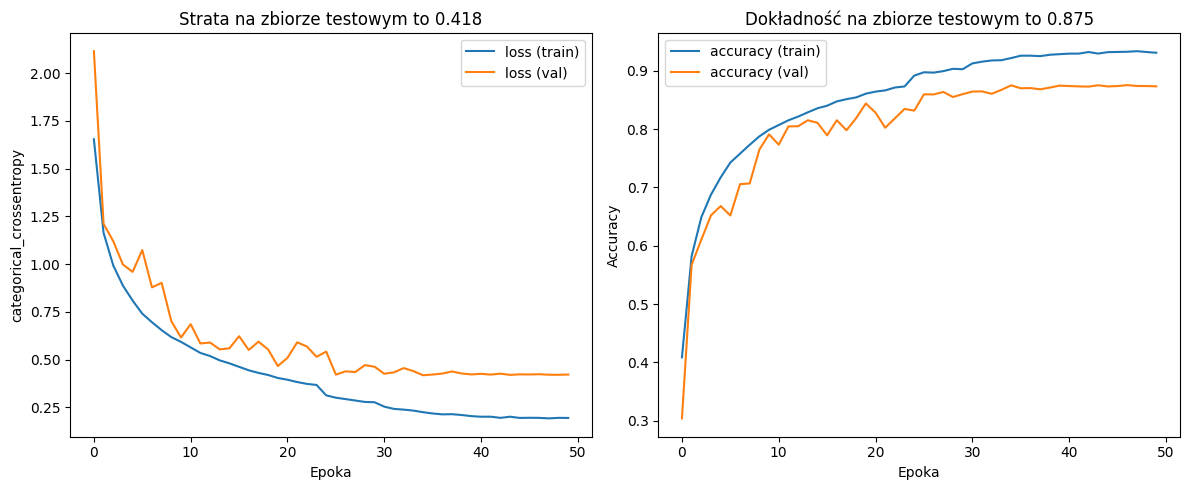

In [80]:
# =========================================================
# --- 8. Wizualizacja przebiegu treningu (loss) ---
# =========================================================
fig_loss_acc = plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='loss (train)')
plt.plot(history.history['val_loss'], label='loss (val)')
plt.xlabel('Epoka')
plt.ylabel('categorical_crossentropy')
plt.title(f'Strata na zbiorze testowym to {loss:.3f}')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='accuracy (train)')
plt.plot(history.history['val_accuracy'], label='accuracy (val)')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.title(f"Dokładność na zbiorze testowym to {accuracy:.3f}")
plt.legend()
plt.tight_layout()

# Zapis wykresu
loss_acc_path = os.path.join(base_export_dir, f'training_loss_accuracy{ts}.png')
fig_loss_acc.savefig(loss_acc_path)
print("Zapisano wykres loss/accuracy ->", loss_acc_path)

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


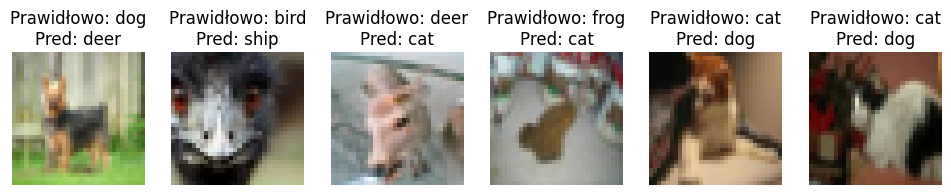

Zapisano macierz pomyłek -> /content/drive/MyDrive/colab_cifar10_exports/confusion_matrix_20251120_203408.png


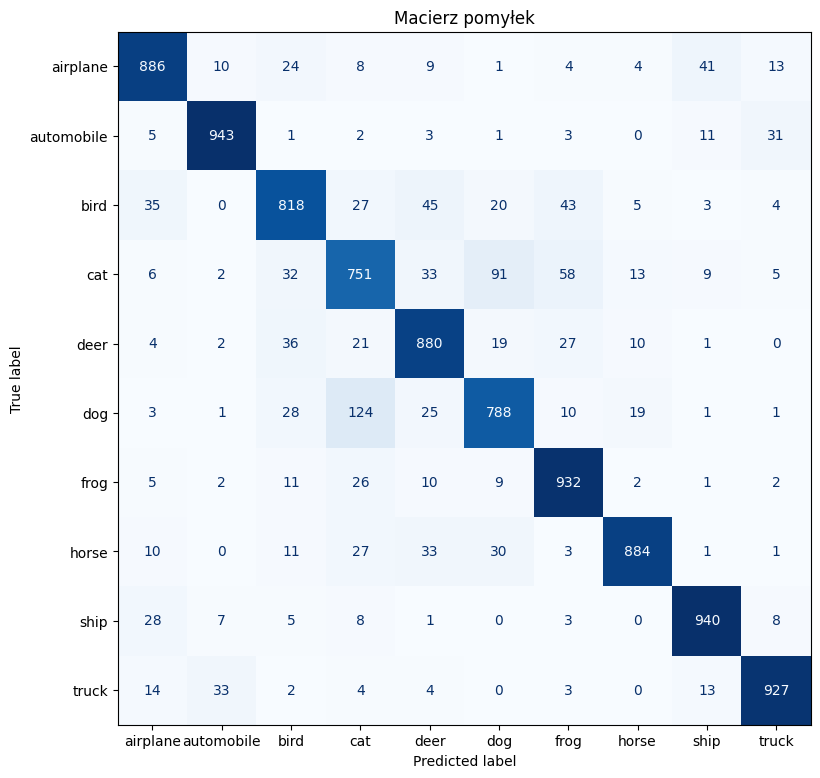

In [81]:
# =========================================================
# --- 9. Wizualizacja błędnych klasyfikacji i macierz pomyłek ---
# =========================================================
# Predykcje (etykiety)
pred_probs = model.predict(x_test)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(y_test_cat, axis=1)  # lub po prostu y_test

# Indeksy błędnych klasyfikacji
incorrect_indices = np.nonzero(pred_labels != true_labels)[0]

# Wyświetlenie kilku błędnych przykładów
n_show = min(6, len(incorrect_indices))
plt.figure(figsize=(12,3))
for i in range(n_show):
    idx = incorrect_indices[i]
    plt.subplot(1, n_show, i+1)
    plt.imshow(x_test[idx])
    plt.title(f"Prawidłowo: {class_names[true_labels[idx]]}\nPred: {class_names[pred_labels[idx]]}")
    plt.axis('off')
plt.show()

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig_cm, ax = plt.subplots(figsize=(9,9))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Macierz pomyłek')
# Zapis wykresu
cm_path = os.path.join(base_export_dir, f'confusion_matrix{ts}.png')
fig_cm.savefig(cm_path)
print("Zapisano macierz pomyłek ->", cm_path)
plt.show()


In [82]:
# =========================================================
# --- 10. Zapis modelu ---
# =========================================================
model_path = os.path.join(base_export_dir, f"my_model{ts}.keras")
model.save(model_path)
print("Model zapisany jako", model_path)

Model zapisany jako /content/drive/MyDrive/colab_cifar10_exports/my_model_20251120_203408.keras
